In [1]:
%load_ext autoreload
%autoreload 2

import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
# from get_radial_profiles_new import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov




/tmp/ipykernel_1468909/495882382.py:13: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


In [2]:
# generate code to call get_xi

# potential_energy -4916.635080802822
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
# merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)

from scipy.interpolate import interp1d
ks = np.geomspace(5e-2,50,15) # wavenumbers
zedges = np.array([0.4, 0.6, 0.8,1.1])
nz_lrg_all = np.loadtxt(abs_path_data + '/pge/desi_lrg_nz.txt')
zv, nzv = nz_lrg_all[:,0], nz_lrg_all[:,1]

nbins_lens = len(zedges) - 1
zarray_lens = np.linspace(0.001, 1.6, 100)
nz_interp = interp1d(zv, nzv, fill_value=1e-10, bounds_error=False)
nz_zarray = nz_interp(zarray_lens)
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = 3
for ji in range(nz_info_dict['nbins_lens']):
    nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-4)
analysis_dict['nz_lens_info_dict'] = nz_info_dict

df_nz_comoving = np.loadtxt(abs_path_data + '/pge/desi_lrg_comoving_density.txt')
zarray_comoving = df_nz_comoving[:,0]
nz_comoving = df_nz_comoving[:,1]
analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
analysis_dict['nbar_gal_comoving_val'] = nz_comoving

from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 5
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])

analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]


analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))

lmin, lmax, dl_log_array = 10.0, 11000.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)
analysis_dict['yy_noise_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')
Ngals_bins = 3.33*np.array([506905, 771875, 859824])
analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))

analysis_dict['symbolic_pk'] = True
analysis_dict['symbolic_hmf'] = True


/tmp/ipykernel_1468909/1008094378.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)


In [3]:
# base_test_orig = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
# profiles_test_orig = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test_orig)
# Pkz_test_orig = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test_orig)
# Cls_test_orig = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test_orig)




In [12]:
import copy
import time 
analysis_dict_copy = copy.deepcopy(analysis_dict)
# analysis_dict_copy['symbolic_pk'] = True
# analysis_dict_copy['symbolic_hmf'] = True
analysis_dict_copy['verbose_time'] = True
ti = time.time()
base_test_symb = base_class(sim_params_dict, halo_params_dict, analysis_dict_copy, other_params_dict)
print('Time taken for base_class symbolic: ', time.time() - ti)
ti = time.time()
profiles_test_symb = Profiles(sim_params_dict, halo_params_dict, analysis_dict_copy, other_params_dict, base_class_obj=base_test_symb)
print('Time taken for profiles symbolic: ', time.time() - ti)
ti = time.time()
Pkz_test_symb = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict_copy, other_params_dict, Profiles_obj=profiles_test_symb)
print('Time taken for Pkz symbolic: ', time.time() - ti)
ti = time.time()
Cls_test_symb = get_Cl(sim_params_dict, halo_params_dict, analysis_dict_copy, other_params_dict, Pkz_obj=Pkz_test_symb)
print('Time taken for Cls symbolic: ', time.time() - ti)




Function 'read_all_input' took 0.0059 seconds
Function 'get_power_spectra_cosmo' took 0.3076 seconds
Time taken for base_class symbolic:  0.3138251304626465
Function 'setup_hmf' took 0.0270 seconds
Function 'get_hmf' took 0.2744 seconds
Function 'get_conc_Mz' took 0.0632 seconds
Function 'setup_main_calc' took 0.2374 seconds
Function 'get_DMO_profiles' took 0.3868 seconds
Function 'run_stars_calc' took 2.6045 seconds
Function 'run_gas_calc' took 0.6329 seconds
Function 'run_clm_calc' took 1.5520 seconds
Function 'run_cga_calc' took 0.0858 seconds
Function 'run_dmb_calc' took 1.5425 seconds
Function 'run_pressure_calc' took 0.5825 seconds
Time taken for profiles symbolic:  7.990030765533447
Time taken for Pkz symbolic:  2.2401957511901855
Time to compute the kappa kappa:  0.14340949058532715
Time to compute the gal gal:  0.13350605964660645
Time to compute the kappa gal:  0.1197965145111084
Time to compute the Pge in the k-array:  0.2169189453125
Time to compute the kappa y:  0.11892914

In [14]:
import pickle as pk

df = pk.load(open(abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod_v3.pk', 'rb'))
probes_all = df['probes']
ell_edges_left = df['edges_left']
ell_edges_right = df['edges_right']
ell_array = df['ell_array']
k_array = df['k_array']
cov_total = df['cov_mat']
Cl_total = df['Cl_Pk']
bin_comb_all_wprobe = df['bin_comb_all_wprobe']





/tmp/ipykernel_1468909/2243355778.py:3: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  df = pk.load(open(abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod_v3.pk', 'rb'))


In [15]:
import copy
from tqdm import tqdm
# from get_power_spectra import get_power_BCMP
get_power_BCMP_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)

nell = len(ell_array)
nk = len(analysis_dict['k_array_survey'])
Cl_all = jnp.zeros((cov_total.shape[0]))
for jp1 in range(len(bin_comb_all_wprobe)):
    binwprobe1 = bin_comb_all_wprobe[jp1]
    probe1 = binwprobe1[0]
    bin_comb1 = binwprobe1[1]
    b1, b2 = bin_comb1[0], bin_comb1[1]
    if probe1 == 'ky':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[:,b1-1])
    if probe1 == 'kk':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[:,b1-1,b2-1])
    if probe1 == 'gg':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[:,b1-1,b2-1])
    if probe1 == 'gk':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[:,b1-1,b2-1])
    if probe1 == 'gy':
        Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[:,b1-1])

edge_left_pge = ell_edges_left[-1]
Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])





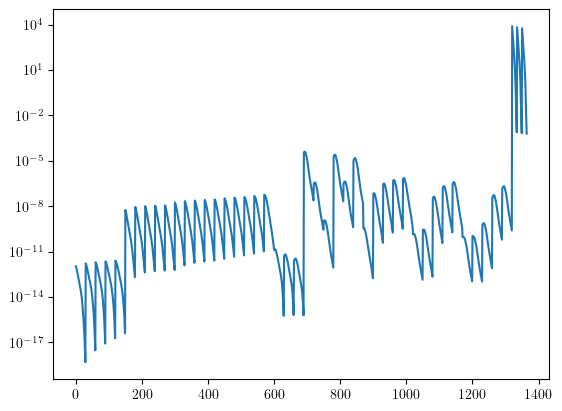

In [24]:
# jnp.all(jnp.isfinite(Cl_all))
# jnp.min(Cl_all), jnp.max(Cl_all)
pl.figure()
pl.plot(Cl_all)
pl.yscale('log')



In [16]:
ell_min_max_dict = {'ky':[0, 11000], 'kk':[0, 11000], 'gg':[0, 11000], 'gk':[0, 11000], 'ge':[0, 11000]}
probes_forecast = ['ky','kk', 'gg', 'gy', 'gk' ,'ge']
# probes_forecast = ['kk', 'gk' ,'ge']
# probes_forecast = ['gg' ,'kk', 'gk','ge']
# probes_forecast = ['gg', 'gk', 'kk' ,'ge']
# probes_forecast = ['gg', 'gk', 'kk' ]
# probes_forecast = ['kk', 'gk' ]
# probes_forecast = ['ky','kk', 'gy', 'gk' ]
ell_sel_min = []
ell_sel_max = []
for jp in range(len(probes_forecast)):
    indp = probes_all.index(probes_forecast[jp])
    # print(indp)
    ell_sel_min.append(ell_edges_left[indp])
    ell_sel_max.append(ell_edges_right[indp])
    print(probes_forecast[jp], ell_sel_min[jp], ell_sel_max[jp])

ell_sel_min = np.array(ell_sel_min)
ell_sel_max = np.array(ell_sel_max)
argsort_min = np.argsort(ell_sel_min)
probes_forecast = [probes_forecast[jp] for jp in argsort_min]
ell_sel_min = ell_sel_min[argsort_min]
ell_sel_max = ell_sel_max[argsort_min]


import yaml

fname = abs_path_data + '/pge/scale_cuts_all_probes_ellmax_8000.yaml'
with open(fname, 'r') as stream:
	sc_all = yaml.load(stream, Loader=yaml.SafeLoader)

ell_sel_all = []
for jp in range(len(probes_forecast)):
    probe = probes_forecast[jp]
    sc_all_jp = sc_all[probe]
    ell_min_jp = ell_sel_min[jp]
    if probe != 'ge':
        for jsc in range(len(sc_all_jp)):
            key = list(sc_all_jp.keys())[jsc]
            scmin_jp_jsc = sc_all_jp[key][0]
            scmax_jp_jsc = sc_all_jp[key][1]
            indsel = np.where((ell_array >= scmin_jp_jsc) & (ell_array <= scmax_jp_jsc))[0]
            ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
            ell_min_jp += nell           
    else:
        for jsc in range(len(sc_all_jp)):
            key = list(sc_all_jp.keys())[jsc]
            scmin_jp_jsc = sc_all_jp[key][0]
            scmax_jp_jsc = sc_all_jp[key][1]
            indsel = np.where((k_array >= scmin_jp_jsc) & (k_array <= scmax_jp_jsc))[0]
            ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
            ell_min_jp += nk
        # ell_max_jp = ell_sel_max[jp]
    # ell_sel_all.append(np.arange(ell_sel_min[jp], ell_sel_max[jp]))
ell_sel_all = np.concatenate(ell_sel_all)


ky 0 150
kk 150 600
gg 690 870
gy 600 690
gk 870 1320
ge 1320 1365


In [17]:
ell_sel_all = []
for jp in range(len(probes_forecast)):
    probe = probes_forecast[jp]
    sc_all_jp = sc_all[probe]
    ell_min_jp = ell_sel_min[jp]
    if probe != 'ge':
        for jsc in range(len(sc_all_jp)):
            key = list(sc_all_jp.keys())[jsc]
            scmin_jp_jsc = sc_all_jp[key][0]
            scmax_jp_jsc = sc_all_jp[key][1]
            indsel = np.where((ell_array >= scmin_jp_jsc) & (ell_array <= scmax_jp_jsc))[0]
            ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
            ell_min_jp += nell           
    else:
        for jsc in range(len(sc_all_jp)):
            key = list(sc_all_jp.keys())[jsc]
            scmin_jp_jsc = sc_all_jp[key][0]
            scmax_jp_jsc = sc_all_jp[key][1]
            indsel = np.where((k_array >= scmin_jp_jsc) & (k_array <= scmax_jp_jsc))[0]
            ell_sel_all.append(np.arange(ell_min_jp + indsel[0], ell_min_jp + indsel[-1]+1))
            ell_min_jp += nk
        # ell_max_jp = ell_sel_max[jp]
    # ell_sel_all.append(np.arange(ell_sel_min[jp], ell_sel_max[jp]))
ell_sel_all = np.concatenate(ell_sel_all)



In [20]:
import jax 
from tqdm import tqdm
import copy

@jax.jit
def get_mean_cosmo(p):
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    for jp in range(len(cosmo_params_vary_names)):
        sim_params_dict_vary['cosmo'][cosmo_params_vary_names[jp]] = p[jp]
    
    get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)

    nell = len(ell_array)
    nk = len(analysis_dict['k_array_survey'])
    Cl_all = jnp.zeros((cov_total.shape[0]))
    for jp1 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        probe1 = binwprobe1[0]
        bin_comb1 = binwprobe1[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        if probe1 == 'ky':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[:,b1-1])
        if probe1 == 'kk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[:,b1-1,b2-1])
        if probe1 == 'gg':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[:,b1-1,b2-1])
        if probe1 == 'gk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[:,b1-1,b2-1])
        if probe1 == 'gy':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[:,b1-1])

    edge_left_pge = ell_edges_left[-1]
    Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
    Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
    Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

    return Cl_all[ell_sel_all]


cosmo_params_vary_names_all = ['Om0', 'Ob0', 'H0', 'ns', 'sigma8']

cosmo_params_fid_all = np.zeros(len(cosmo_params_vary_names_all))
for jp in range(len(cosmo_params_vary_names_all)):
    cosmo_params_fid_all[jp] = sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]

dmu_cosmo_all = np.zeros((len(ell_sel_all), len(cosmo_params_vary_names_all)))
for jp in tqdm(range(len(cosmo_params_vary_names_all))):
    cosmo_params_vary_names = [cosmo_params_vary_names_all[jp]]
    params_fid = jnp.array([sim_params_dict['cosmo'][cosmo_params_vary_names_all[jp]]])

    jac_mean = jax.jit(jax.jacfwd(get_mean_cosmo))
    dmu_cosmo = jac_mean(params_fid)
    dmu_cosmo_all[:, jp] = dmu_cosmo[:,0]




100%|██████████| 5/5 [02:46<00:00, 33.30s/it]


In [21]:
dmu_cosmo_all


array([[ 2.26001123e-12,             nan,             nan,
         1.55468871e-12,  2.49324573e-12],
       [ 2.18227384e-12,             nan,             nan,
         1.48592659e-12,  2.36338327e-12],
       [ 2.15616078e-12,             nan,             nan,
         1.42393729e-12,  2.18871871e-12],
       ...,
       [-2.95863946e+01,             nan,             nan,
         3.15028414e+00,  8.75817432e-01],
       [-1.05874673e+01,             nan,             nan,
         2.39245801e-01, -1.69567084e-01],
       [-3.38150192e+00,             nan,             nan,
        -3.17805927e-01, -4.16287038e-01]])

In [22]:
import jax 
from tqdm import tqdm

@jax.jit
def get_mean_sims(p):
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    for jp in range(len(sim_param_vary_names)):
        sim_params_dict_vary[sim_param_vary_names[jp]] = p[jp]
    
    get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)

    nell = len(ell_array)
    nk = len(analysis_dict['k_array_survey'])
    Cl_all = jnp.zeros((cov_total.shape[0]))
    for jp1 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        probe1 = binwprobe1[0]
        bin_comb1 = binwprobe1[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        if probe1 == 'ky':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[:,b1-1])
        if probe1 == 'kk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[:,b1-1,b2-1])
        if probe1 == 'gg':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[:,b1-1,b2-1])
        if probe1 == 'gk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[:,b1-1,b2-1])
        if probe1 == 'gy':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[:,b1-1])

    edge_left_pge = ell_edges_left[-1]
    Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
    Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
    Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

    return Cl_all[ell_sel_all]


# sim_params_dict['nu_theta_ej_M'] = 0.1
# sim_params_dict['eta_star'] = 0.3
# sims_params_vary_names_all = ['theta_ej_0', 'mu_beta' ,'alpha_nt']
# sims_params_vary_names_all = ['theta_ej_0', 'mu_beta','nu_theta_ej_z', 'delta_rhogas', 'gamma_rhogas']
# sims_params_vary_names_all = ['theta_ej_0', 'mu_beta','delta_rhogas', 'gamma_rhogas']
# sims_params_vary_names_all = ['theta_ej_0', 'mu_beta','delta_rhogas', 'gamma_rhogas','nu_theta_ej_M','eta_star','alpha_nt']
sims_params_vary_names_all = ['nu_theta_ej_M','eta_star','alpha_nt']



sims_params_fid_all = np.zeros(len(sims_params_vary_names_all))
for jp in range(len(sims_params_vary_names_all)):
    sims_params_fid_all[jp] = sim_params_dict[sims_params_vary_names_all[jp]]

dmu_sims_all = np.zeros((len(ell_sel_all), len(sims_params_vary_names_all)))
for jp in tqdm(range(len(sims_params_vary_names_all))):
    sim_param_vary_names = [sims_params_vary_names_all[jp]]
    params_fid = jnp.array([sim_params_dict[sims_params_vary_names_all[jp]]])

    jac_mean = jax.jit(jax.jacfwd(get_mean_sims))
    dmu_sim = jac_mean(params_fid)
    dmu_sims_all[:,jp] = dmu_sim[:,0]

# F_sims = jnp.matmul(dmu_sims_all.T, jnp.matmul(P, dmu_sims_all))
# # print(np.linalg.cond(F_sims))
# cov_sims_params = np.linalg.inv(F_sims)
# print(np.sqrt(np.diag(cov_sims_params)))




100%|██████████| 3/3 [01:11<00:00, 23.95s/it]


In [23]:
import jax 
from tqdm import tqdm

@jax.jit
def get_mean_IA(p):
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)

    for jp in range(len(IA_param_vary_names)):
        other_params_dict_vary[IA_param_vary_names[jp]] = p[jp]
    
    get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)

    nell = len(ell_array)
    nk = len(analysis_dict['k_array_survey'])
    Cl_all = jnp.zeros((cov_total.shape[0]))
    for jp1 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        probe1 = binwprobe1[0]
        bin_comb1 = binwprobe1[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        if probe1 == 'ky':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_y_tot_mat[:,b1-1])
        if probe1 == 'kk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_kappa_kappa_tot_mat[:,b1-1,b2-1])
        if probe1 == 'gg':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_gal_tot_mat[:,b1-1,b2-1])
        if probe1 == 'gk':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_kappa_tot_mat[:,b1-1,b2-1])
        if probe1 == 'gy':
            Cl_all = Cl_all.at[jp1*nell:(jp1+1)*nell].set(get_power_BCMP_test.Cl_gal_y_tot_mat[:,b1-1])

    edge_left_pge = ell_edges_left[-1]
    Cl_all = Cl_all.at[edge_left_pge:edge_left_pge+nk].set(get_power_BCMP_test.Pge_tot_mat[0,:])
    Cl_all = Cl_all.at[edge_left_pge+nk:edge_left_pge+2*nk].set(get_power_BCMP_test.Pge_tot_mat[1,:])
    Cl_all = Cl_all.at[edge_left_pge+2*nk:edge_left_pge+3*nk].set(get_power_BCMP_test.Pge_tot_mat[2,:])

    return Cl_all[ell_sel_all]

IA_params_vary_names_all = ['A_IA', 'eta_IA']

IA_params_fid_all = np.zeros(len(IA_params_vary_names_all))
for jp in range(len(IA_params_vary_names_all)):
    IA_params_fid_all[jp] = other_params_dict[IA_params_vary_names_all[jp]]

dmu_IA_all = np.zeros((len(ell_sel_all), len(IA_params_vary_names_all)))
for jp in tqdm(range(len(IA_params_vary_names_all))):
    IA_param_vary_names = [IA_params_vary_names_all[jp]]
    params_fid = jnp.array([other_params_dict[IA_params_vary_names_all[jp]]])

    jac_mean = jax.jit(jax.jacfwd(get_mean_IA))
    dmu_IA = jac_mean(params_fid)
    dmu_IA_all[:, jp] = dmu_IA[:, 0]




100%|██████████| 2/2 [00:43<00:00, 21.80s/it]


In [24]:
# in a 2d matrix select multiple slice ranging from different min and max values
cov_forecast = cov_total[ell_sel_all,:][:, ell_sel_all]



In [25]:
# P = jnp.linalg.inv(cov_forecast)

# F_sims = jnp.matmul(dmu_cosmo_all.T, jnp.matmul(P, dmu_cosmo_all))

# print(F_sims.shape)
# print(F_sims)
# dmu_cosmo_all
# params_fid
dmu_all = np.concatenate([dmu_cosmo_all, dmu_sims_all, dmu_IA_all], axis=1)
# dmu_all = np.concatenate([dmu_cosmo_all, dmu_sims_all], axis=1)
# dmu_all = np.concatenate([dmu_cosmo_all.T, dmu_sims_all.T, dmu_IA_all.T, dmu_mult_shear_all, dmu_bias_Deltaz_all], axis=1)
# dmu_all.shape

P = jnp.linalg.inv(cov_forecast)

F_all = jnp.matmul(dmu_all.T, jnp.matmul(P, dmu_all))

print(F_all.shape)




(10, 10)


In [27]:
np.linalg.inv(F_all)
# np.linalg.cond(F_all)



array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]])

In [36]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as pl
def plot_contours(fisher, pos, inds=[1,0], nstd=1., ax=None,title=None, **kwargs):
  """
  Plot 2D parameter contours given a Hessian matrix of the likelihood
  """
  i,j = inds
  
  def eigsorted(cov):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    return vals[order], vecs[:, order]

  mat = fisher
  cov = np.linalg.inv(mat)
  sigma_marg = lambda i: np.sqrt(cov[i, i])

  if ax is None:
      ax = pl.gca()

  # Extracts the block we are interested in
  block_cov = cov[:,[i,j]][[i,j],:]
  vals, vecs = eigsorted(block_cov)
  theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

  # Width and height are "full" widths, not radius
  width, height = 2 * nstd * np.sqrt(vals)
  ellip = Ellipse(xy=pos[[i,j]], width=width,
                  height=height, angle=theta, **kwargs)

  ax.add_artist(ellip)
  sz = max(width, height)
  s1 = 1.5*nstd*sigma_marg(i)
  s2 = 1.5*nstd*sigma_marg(j)
  ax.set_xlim(pos[i] - s1, pos[i] + s1)
  ax.set_ylim(pos[j] - s2, pos[j] + s2)
  pl.draw()
  pl.xlabel(r'$\Omega_m$', fontsize=16)
  pl.ylabel(r'$\sigma_8$', fontsize=16)
  # pl.xlim(0.305, 0.325)
  # pl.ylim(0.8325, 0.85)
  if title is not None:
    pl.title(title, fontsize=16)
  return ellip



/tmp/ipykernel_1345957/570373872.py:27: RuntimeWarning: invalid value encountered in sqrt
  width, height = 2 * nstd * np.sqrt(vals)
/tmp/ipykernel_1345957/570373872.py:16: RuntimeWarning: invalid value encountered in sqrt
  sigma_marg = lambda i: np.sqrt(cov[i, i])


ValueError: Axis limits cannot be NaN or Inf

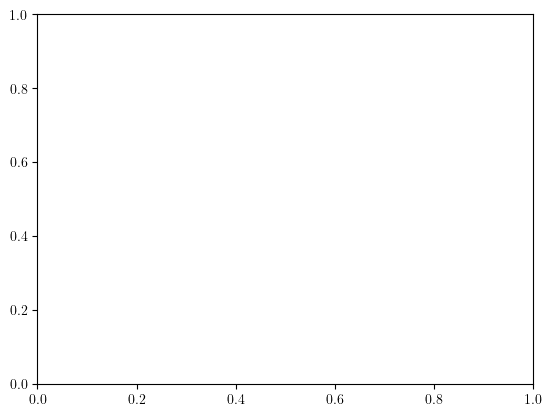

In [37]:
# plot_contours(F_sims, cosmo_params_fid_all, inds=[0,4], title='with Pge')
plot_contours(F_all, cosmo_params_fid_all, inds=[0,4], title='with Pge')




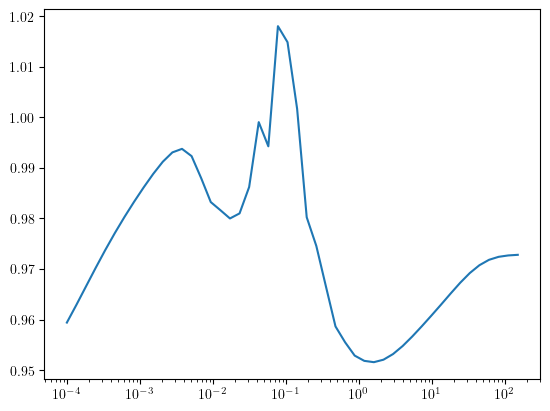

In [6]:
pl.figure()
pl.plot(Pkz_test_orig.kPk_array, np.array(Pkz_test_orig.Pmm_dmb_tot_mat[:,5]/Pkz_test_symb.Pmm_dmb_tot_mat[:,5]), label='0h')
pl.xscale('log')
# pl.yscale('log')
# pl.ylim(0.8, 1.1)
# pl.xlim(1e-4, 5)



Text(0.5, 0, '$M$')

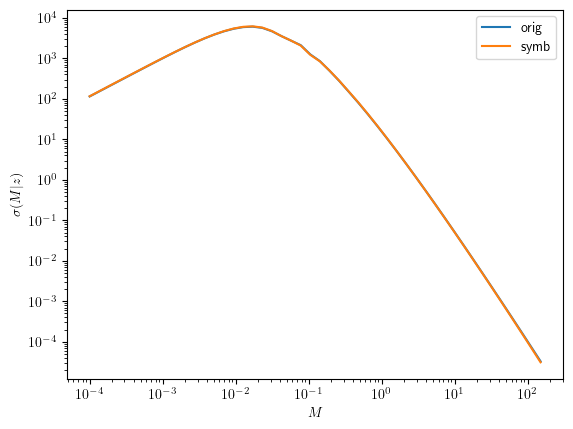

In [7]:
jz = 20
pl.figure()
pl.plot(profiles_test_orig.kPk_array, profiles_test_orig.plin_kz_mat[:,jz], label='orig')
pl.plot(profiles_test_symb.kPk_array, profiles_test_symb.plin_kz_mat[:,jz], label='symb')
# pl.plot(profiles_test_symb.k_array, profiles_test_orig.sigma_Mz_mat[jz,:]/profiles_test_symb.sigma_Mz_mat[jz,:], label='symb')
pl.legend()
pl.xscale('log')
pl.yscale('log')
pl.ylabel(r'$\sigma(M|z)$')
pl.xlabel(r'$M$')



Text(0.5, 0, '$M$')

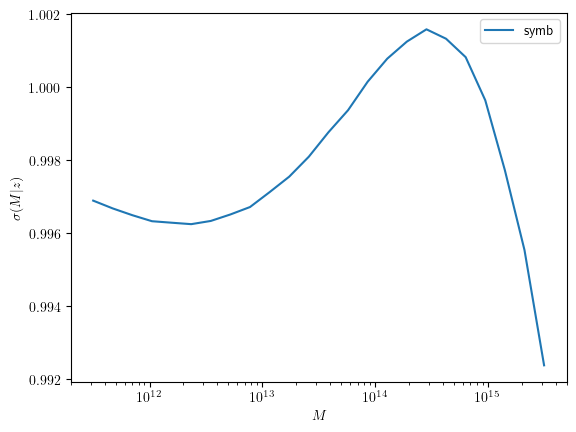

In [8]:
jz = 20
pl.figure()
# pl.plot(profiles_test_orig.M_array, profiles_test_orig.sigma_Mz_mat[jz,:], label='orig')
# pl.plot(profiles_test_symb.M_array, profiles_test_symb.sigma_Mz_mat[jz,:], label='symb')
pl.plot(profiles_test_symb.M_array, profiles_test_orig.sigma_Mz_mat[jz,:]/profiles_test_symb.sigma_Mz_mat[jz,:], label='symb')
pl.legend()
pl.xscale('log')
# pl.yscale('log')
pl.ylabel(r'$\sigma(M|z)$')
pl.xlabel(r'$M$')


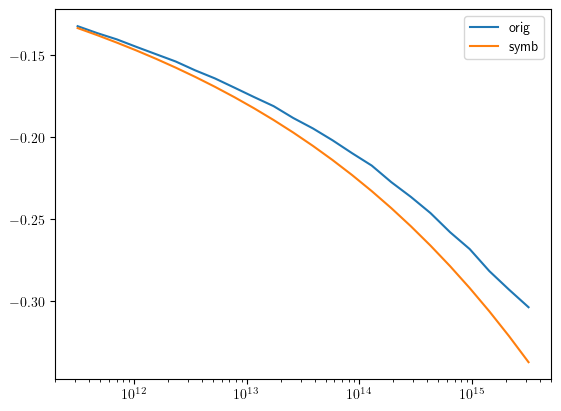

In [19]:
# profiles_test_orig.hmf_Mz_mat.shape
pl.figure()
pl.plot(profiles_test_orig.M_array, profiles_test_orig.dlgsig_dlnM_mat[5,:], label='orig')
pl.plot(profiles_test_symb.M_array, profiles_test_symb.dlgsig_dlnM_mat[5,:], label='symb')
pl.legend()
pl.xscale('log')
# pl.yscale('log')


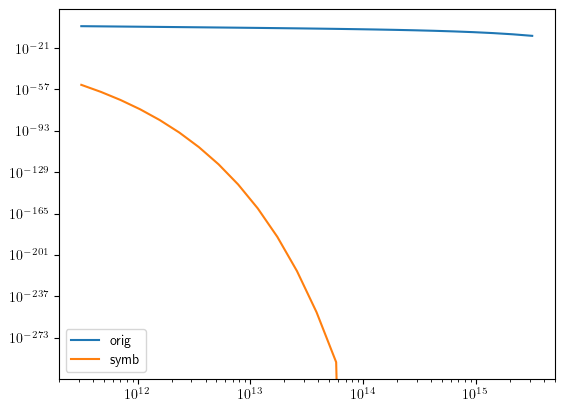

In [ ]:
# profiles_test_orig.hmf_Mz_mat.shape
pl.figure()
pl.plot(profiles_test_orig.M_array, profiles_test_orig.hmf_Mz_mat[5,:], label='orig')
pl.plot(profiles_test_symb.M_array, profiles_test_symb.hmf_Mz_mat[5,:], label='symb')
pl.legend()
pl.xscale('log')
pl.yscale('log')


In [ ]:
pl.figure()
pl.plot(Pkz_test_orig.kPk_array, np.array(Pkz_test_orig.Pmm_dmb_tot_mat[:,5]/Pkz_test_symb.Pmm_dmb_tot_mat[:,5]), label='0h')
pl.xscale('log')
pl.yscale('log')
# pl.ylim(0.8, 1.1)
# pl.xlim(1e-4, 5)

